In [ ]:
# Install required packages
!pip install gradio tensorflow keras pillow numpy matplotlib scikit-learn -q

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten, Input, Average
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from PIL import Image
import gradio as gr
import os
import seaborn as sns

In [ ]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']  # Update based on your folder names

def preprocess_image(image):
    """Preprocess single image for prediction"""
    if isinstance(image, str):
        img = Image.open(image).convert('RGB')
    else:
        img = Image.fromarray(image).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def create_data_generators(train_dir, test_dir=None):
    """Create train/validation/test data generators with augmentation"""

    # Training data augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2
    )

    # No augmentation for test data
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',  # Multi-class classification
        subset='training',
        shuffle=True
    )

    val_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )

    test_generator = None
    if test_dir:
        test_generator = test_datagen.flow_from_directory(
            test_dir,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )

    # Update class names from generator
    global CLASS_NAMES
    CLASS_NAMES = list(train_generator.class_indices.keys())
    print(f"Classes found: {CLASS_NAMES}")

    return train_generator, val_generator, test_generator

In [ ]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    """Build custom CNN model for multi-class classification"""
    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)  # Softmax for multi-class

    model = Model(inputs, outputs, name='CustomCNN')
    return model

def build_mobilenet(input_shape=(224, 224, 3), num_classes=4):
    """Build MobileNetV2 model for multi-class classification"""
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze early layers, fine-tune later layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)  # Softmax for multi-class

    model = Model(base_model.input, outputs, name='MobileNetV2')
    return model

def build_ensemble(cnn_model, mobilenet_model, input_shape=(224, 224, 3)):
    """Build ensemble model by averaging predictions"""
    inputs = Input(shape=input_shape)

    cnn_pred = cnn_model(inputs)
    mobilenet_pred = mobilenet_model(inputs)

    # Average ensemble
    ensemble_output = Average()([cnn_pred, mobilenet_pred])

    ensemble_model = Model(inputs, ensemble_output, name='EnsembleModel')
    return ensemble_model

In [ ]:
import time
from IPython.display import clear_output, display
import pandas as pd

class TrainingProgressCallback(tf.keras.callbacks.Callback):
    """Custom callback to display training progress"""

    def __init__(self, model_name="Model"):
        super().__init__()
        self.model_name = model_name
        self.history_df = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        self.epoch_times = []
        print(f"\n{'='*60}")
        print(f"  TRAINING {self.model_name.upper()}")
        print(f"{'='*60}")
        print(f"{'Epoch':<8}{'Train Loss':<14}{'Train Acc':<14}{'Val Loss':<14}{'Val Acc':<14}{'Time':<10}")
        print(f"{'-'*60}")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start
        self.epoch_times.append(epoch_time)

        train_loss = logs.get('loss', 0)
        train_acc = logs.get('accuracy', 0) * 100
        val_loss = logs.get('val_loss', 0)
        val_acc = logs.get('val_accuracy', 0) * 100

        print(f"{epoch+1:<8}{train_loss:<14.4f}{train_acc:<14.2f}%{val_loss:<14.4f}{val_acc:<14.2f}%{epoch_time:<10.2f}s")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.start_time
        print(f"{'-'*60}")
        print(f"Training completed in {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
        print(f"Best Validation Accuracy: {max(self.model.history.history['val_accuracy'])*100:.2f}%")
        print(f"{'='*60}\n")


def train_models_verbose(train_dir, test_dir=None, epochs=25):
    """Train CNN and MobileNet models with detailed progress output"""

    print("\n" + "="*60)
    print("  STEP 1: LOADING AND PREPROCESSING DATA")
    print("="*60)

    train_gen, val_gen, test_gen = create_data_generators(train_dir, test_dir)

    print(f"\nDataset Summary:")
    print(f"  - Training samples: {train_gen.samples}")
    print(f"  - Validation samples: {val_gen.samples}")
    if test_gen:
        print(f"  - Test samples: {test_gen.samples}")
    print(f"  - Number of classes: {NUM_CLASSES}")
    print(f"  - Classes: {CLASS_NAMES}")
    print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
    print(f"  - Batch size: {BATCH_SIZE}")

    # ==================== BUILD MODELS ====================
    print("\n" + "="*60)
    print("  STEP 2: BUILDING MODELS")
    print("="*60)

    print("\nBuilding Custom CNN...")
    cnn_model = build_custom_cnn(num_classes=NUM_CLASSES)
    print(f"  - Total parameters: {cnn_model.count_params():,}")
    print(f"  - Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in cnn_model.trainable_weights]):,}")

    print("\nBuilding MobileNetV2...")
    mobilenet_model = build_mobilenet(num_classes=NUM_CLASSES)
    print(f"  - Total parameters: {mobilenet_model.count_params():,}")
    print(f"  - Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in mobilenet_model.trainable_weights]):,}")

    # ==================== COMPILE MODELS ====================
    print("\n" + "="*60)
    print("  STEP 3: COMPILING MODELS")
    print("="*60)

    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print("\nCNN compiled with:")
    print("  - Optimizer: Adam (lr=0.001)")
    print("  - Loss: Categorical Crossentropy")
    print("  - Metrics: Accuracy")

    mobilenet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print("\nMobileNetV2 compiled with:")
    print("  - Optimizer: Adam (lr=0.0001)")
    print("  - Loss: Categorical Crossentropy")
    print("  - Metrics: Accuracy")

    # ==================== TRAIN CNN ====================
    print("\n" + "="*60)
    print("  STEP 4: TRAINING CUSTOM CNN")
    print("="*60)

    cnn_callbacks = [
        TrainingProgressCallback("Custom CNN"),
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=0),
        ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint('best_cnn.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
    ]

    cnn_history = cnn_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=cnn_callbacks,
        verbose=0  # We use custom callback for output
    )

    # ==================== TRAIN MOBILENET ====================
    print("\n" + "="*60)
    print("  STEP 5: TRAINING MOBILENETV2")
    print("="*60)

    mobilenet_callbacks = [
        TrainingProgressCallback("MobileNetV2"),
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=0),
        ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint('best_mobilenet.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
    ]

    mobilenet_history = mobilenet_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=mobilenet_callbacks,
        verbose=0
    )

    # ==================== BUILD ENSEMBLE ====================
    print("\n" + "="*60)
    print("  STEP 6: BUILDING ENSEMBLE MODEL")
    print("="*60)

    ensemble_model = build_ensemble(cnn_model, mobilenet_model)
    ensemble_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
    print("\nEnsemble model created by averaging CNN and MobileNet predictions")
    print(f"  - Total parameters: {ensemble_model.count_params():,}")

    # ==================== SAVE MODELS ====================
    print("\n" + "="*60)
    print("  STEP 7: SAVING MODELS")
    print("="*60)

    cnn_model.save('cnn_model.keras')
    print("  - Saved: cnn_model.keras")

    mobilenet_model.save('mobilenet_model.keras')
    print("  - Saved: mobilenet_model.keras")

    ensemble_model.save('ensemble_model.keras')
    print("  - Saved: ensemble_model.keras")

    np.save('class_names.npy', CLASS_NAMES)
    print("  - Saved: class_names.npy")

    # ==================== FINAL SUMMARY ====================
    print("\n" + "="*60)
    print("  TRAINING SUMMARY")
    print("="*60)

    cnn_best_acc = max(cnn_history.history['val_accuracy']) * 100
    mobilenet_best_acc = max(mobilenet_history.history['val_accuracy']) * 100

    print(f"\n{'Model':<20}{'Best Val Accuracy':<20}{'Final Train Acc':<20}")
    print(f"{'-'*60}")
    print(f"{'Custom CNN':<20}{cnn_best_acc:<20.2f}%{cnn_history.history['accuracy'][-1]*100:<20.2f}%")
    print(f"{'MobileNetV2':<20}{mobilenet_best_acc:<20.2f}%{mobilenet_history.history['accuracy'][-1]*100:<20.2f}%")
    print(f"{'-'*60}")

    # Evaluate ensemble on validation set
    print("\nEvaluating Ensemble Model on Validation Set...")
    val_gen.reset()
    ensemble_eval = ensemble_model.evaluate(val_gen, verbose=0)
    print(f"Ensemble Validation Accuracy: {ensemble_eval[1]*100:.2f}%")

    print("\n" + "="*60)
    print("  ALL STEPS COMPLETED SUCCESSFULLY!")
    print("="*60)

    return ensemble_model, cnn_model, mobilenet_model, cnn_history, mobilenet_history, test_gen


# ===== RUN TRAINING =====
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

# Set your dataset paths
train_dir = '/content/drive/MyDrive/dataset/Training'
test_dir = '/content/drive/MyDrive/dataset/Testing'

# Train models with verbose output
ensemble, cnn, mobilenet, cnn_hist, mobile_hist, test_gen = train_models_verbose(
    train_dir,
    test_dir,
    epochs=20
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  STEP 1: LOADING AND PREPROCESSING DATA
Found 4490 images belonging to 4 classes.
Found 1122 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']

Dataset Summary:
  - Training samples: 4490
  - Validation samples: 1122
  - Test samples: 1600
  - Number of classes: 4
  - Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  - Image size: 224x224
  - Batch size: 32

  STEP 2: BUILDING MODELS

Building Custom CNN...
  - Total parameters: 652,356
  - Trainable parameters: 652,356

Building MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  - Total parameters: 3,046,212
  - Trainable parameters: 2,314,628

  STEP 3: COMPILING MODELS

CNN compiled with:
  - Optimizer: Adam (lr=0.001)
  - Loss: Categorical Crossentropy
  - Metrics: Accuracy

MobileNetV2 compil


  STEP 8: MODEL EVALUATION ON TEST SET

Evaluating Custom CNN...
  - Test Loss: 1.1699
  - Test Accuracy: 69.69%

Evaluating MobileNetV2...
  - Test Loss: 0.3036
  - Test Accuracy: 92.19%

Evaluating Ensemble Model...
  - Test Loss: 0.4477
  - Test Accuracy: 90.06%

  MODEL COMPARISON

Model               Test Loss      Test Accuracy  
--------------------------------------------------
Custom CNN          1.1699         69.69          %
MobileNetV2         0.3036         92.19          %
Ensemble            0.4477         90.06          %
--------------------------------------------------

  CLASSIFICATION REPORT (ENSEMBLE)

              precision    recall  f1-score   support

      glioma       0.92      0.80      0.85       400
  meningioma       0.91      0.81      0.86       400
     notumor       0.86      1.00      0.93       400
   pituitary       0.91      0.99      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0

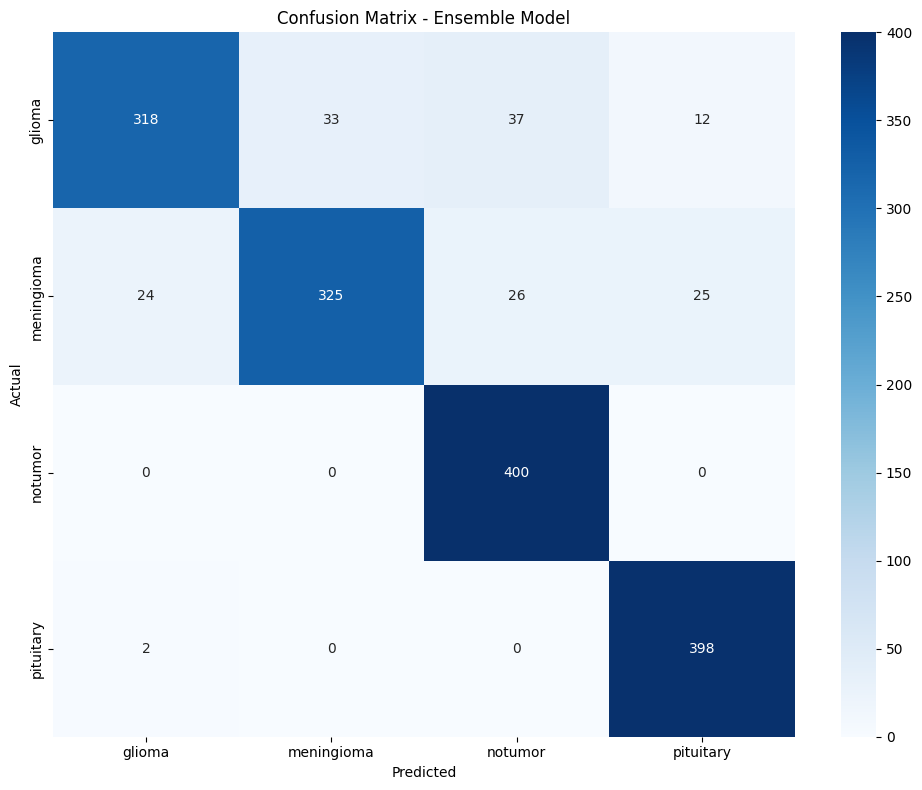


  EVALUATION COMPLETED!


In [ ]:
def evaluate_models_verbose(ensemble_model, cnn_model, mobilenet_model, test_generator, class_names):
    """Evaluate all models with detailed output"""

    print("\n" + "="*60)
    print("  STEP 8: MODEL EVALUATION ON TEST SET")
    print("="*60)

    test_generator.reset()

    # Evaluate each model
    print("\nEvaluating Custom CNN...")
    cnn_eval = cnn_model.evaluate(test_generator, verbose=0)
    print(f"  - Test Loss: {cnn_eval[0]:.4f}")
    print(f"  - Test Accuracy: {cnn_eval[1]*100:.2f}%")

    test_generator.reset()
    print("\nEvaluating MobileNetV2...")
    mobilenet_eval = mobilenet_model.evaluate(test_generator, verbose=0)
    print(f"  - Test Loss: {mobilenet_eval[0]:.4f}")
    print(f"  - Test Accuracy: {mobilenet_eval[1]*100:.2f}%")

    test_generator.reset()
    print("\nEvaluating Ensemble Model...")
    ensemble_eval = ensemble_model.evaluate(test_generator, verbose=0)
    print(f"  - Test Loss: {ensemble_eval[0]:.4f}")
    print(f"  - Test Accuracy: {ensemble_eval[1]*100:.2f}%")

    # Comparison table
    print("\n" + "="*60)
    print("  MODEL COMPARISON")
    print("="*60)
    print(f"\n{'Model':<20}{'Test Loss':<15}{'Test Accuracy':<15}")
    print(f"{'-'*50}")
    print(f"{'Custom CNN':<20}{cnn_eval[0]:<15.4f}{cnn_eval[1]*100:<15.2f}%")
    print(f"{'MobileNetV2':<20}{mobilenet_eval[0]:<15.4f}{mobilenet_eval[1]*100:<15.2f}%")
    print(f"{'Ensemble':<20}{ensemble_eval[0]:<15.4f}{ensemble_eval[1]*100:<15.2f}%")
    print(f"{'-'*50}")

    # Classification report
    print("\n" + "="*60)
    print("  CLASSIFICATION REPORT (ENSEMBLE)")
    print("="*60)

    test_generator.reset()
    predictions = ensemble_model.predict(test_generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    print("\n" + classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    print("\n" + "="*60)
    print("  CONFUSION MATRIX")
    print("="*60)

    cm = confusion_matrix(y_true, y_pred)

    # Print text-based confusion matrix
    print(f"\n{'Actual \\ Predicted':<15}", end="")
    for name in class_names:
        print(f"{name:<12}", end="")
    print()
    print("-" * (15 + 12 * len(class_names)))

    for i, name in enumerate(class_names):
        print(f"{name:<15}", end="")
        for j in range(len(class_names)):
            print(f"{cm[i][j]:<12}", end="")
        print()

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Ensemble Model')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()

    print("\n" + "="*60)
    print("  EVALUATION COMPLETED!")
    print("="*60)

    return cnn_eval, mobilenet_eval, ensemble_eval

# Run evaluation
cnn_eval, mobile_eval, ensemble_eval = evaluate_models_verbose(
    ensemble, cnn, mobilenet, test_gen, CLASS_NAMES
)


  STEP 9: VISUALIZING TRAINING HISTORY


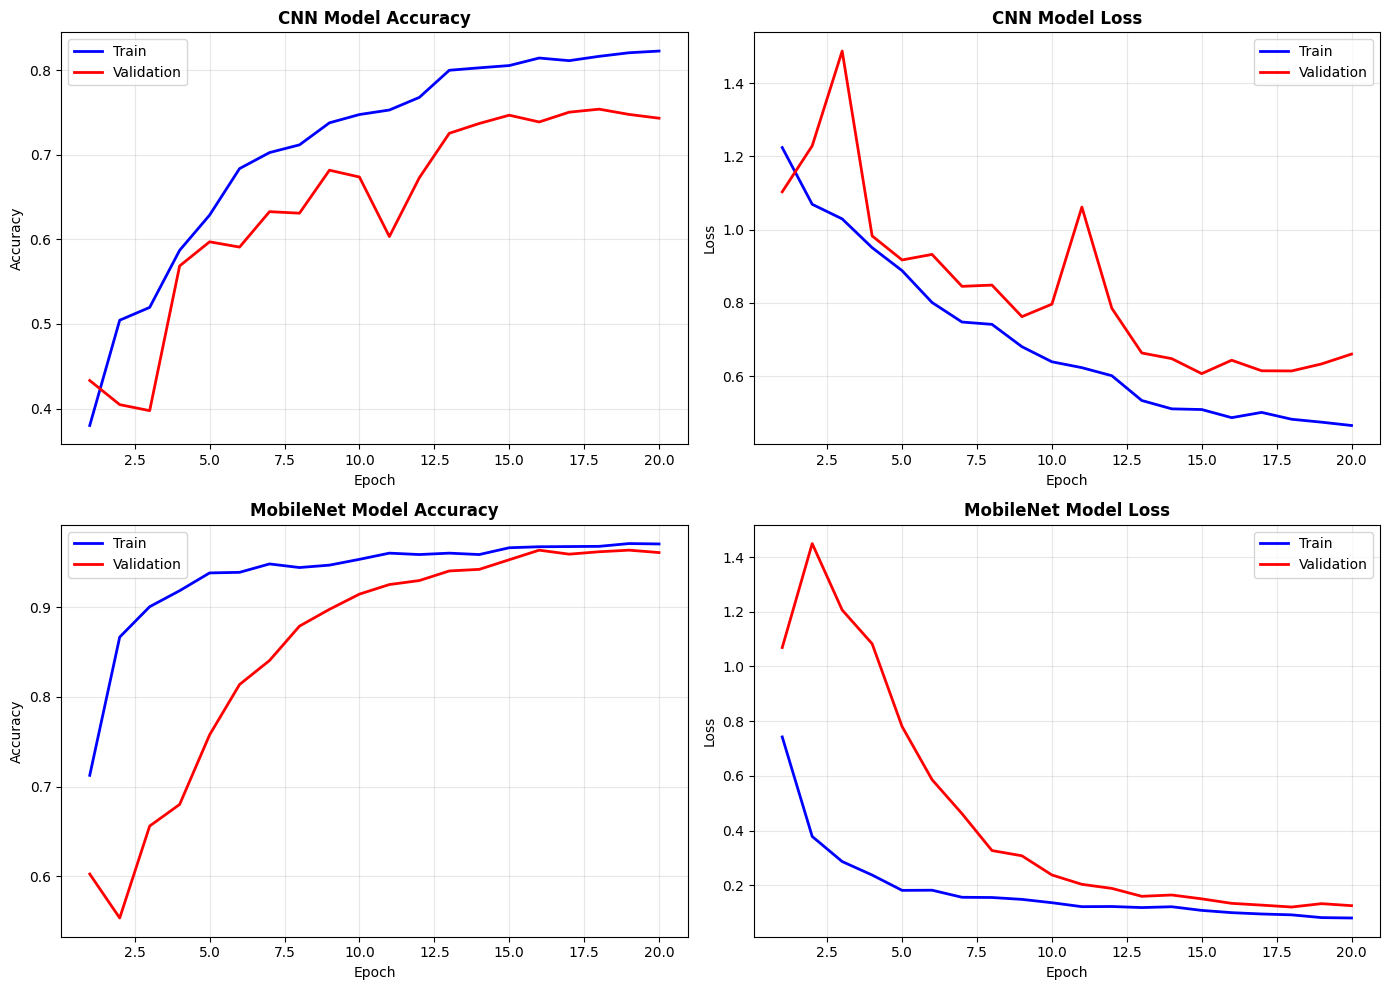


Training history plot saved as 'training_history.png'


In [ ]:
def plot_training_history_detailed(cnn_history, mobilenet_history):
    """Plot detailed training history"""

    print("\n" + "="*60)
    print("  STEP 9: VISUALIZING TRAINING HISTORY")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    epochs_cnn = range(1, len(cnn_history.history['accuracy']) + 1)
    epochs_mobile = range(1, len(mobilenet_history.history['accuracy']) + 1)

    # CNN Accuracy
    axes[0, 0].plot(epochs_cnn, cnn_history.history['accuracy'], 'b-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs_cnn, cnn_history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
    axes[0, 0].set_title('CNN Model Accuracy', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # CNN Loss
    axes[0, 1].plot(epochs_cnn, cnn_history.history['loss'], 'b-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs_cnn, cnn_history.history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 1].set_title('CNN Model Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # MobileNet Accuracy
    axes[1, 0].plot(epochs_mobile, mobilenet_history.history['accuracy'], 'b-', label='Train', linewidth=2)
    axes[1, 0].plot(epochs_mobile, mobilenet_history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
    axes[1, 0].set_title('MobileNet Model Accuracy', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # MobileNet Loss
    axes[1, 1].plot(epochs_mobile, mobilenet_history.history['loss'], 'b-', label='Train', linewidth=2)
    axes[1, 1].plot(epochs_mobile, mobilenet_history.history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1, 1].set_title('MobileNet Model Loss', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

    print("\nTraining history plot saved as 'training_history.png'")

# Plot history
plot_training_history_detailed(cnn_hist, mobile_hist)

In [ ]:
import numpy as np
import json

class_names = np.load('/content/class_names.npy').tolist()

config = {
    "img_size": 224,
    "class_names": class_names
}

with open('/content/config.json', 'w') as f:
    json.dump(config, f)

print("✅ config.json created from numpy!")

✅ config.json created from numpy!


In [ ]:
import os
import shutil
import zipfile
from google.colab import files

def download_models():
    print("\n" + "="*70)
    print("  PREPARING MODEL FILES")
    print("="*70)

    # Step 1: Create clean deployment folder
    deploy_dir = '/content/brain_tumor_models'
    os.makedirs(deploy_dir, exist_ok=True)

    # Step 2: Copy required files (edit if needed)
    required_files = [
        '/content/ensemble_model.keras',
        '/content/config.json',          # comment this if not present
        '/content/class_names.npy'       # optional
    ]

    copied = 0
    for file_path in required_files:
        if os.path.exists(file_path):
            shutil.copy(file_path, deploy_dir)
            print(f"✅ Copied: {os.path.basename(file_path)}")
            copied += 1
        else:
            print(f"⚠️ Not found: {file_path}")

    if copied == 0:
        print("❌ No files copied. Check file paths!")
        return

    # Step 3: Create ZIP
    print("\nCreating ZIP file...")
    zip_path = '/content/brain_tumor_models.zip'

    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files_list in os.walk(deploy_dir):
            for file in files_list:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, deploy_dir)
                zipf.write(file_path, arcname)

    # Step 4: Show info
    size_mb = os.path.getsize(zip_path) / (1024**2)
    print(f"\n✅ ZIP created: brain_tumor_models.zip")
    print(f"📦 Size: {size_mb:.2f} MB")

    # Step 5: Download
    print("\n⬇️ Download starting...")
    files.download(zip_path)

    print("\n" + "="*70)
    print("  DONE!")
    print("="*70)
    print("\nNext steps:")
    print("1. Extract ZIP")
    print("2. Put files inside your 'code/' folder")
    print("3. Push to GitHub")
    print("4. Redeploy Streamlit")

# Run
download_models()


  PREPARING MODEL FILES
✅ Copied: ensemble_model.keras
✅ Copied: config.json
✅ Copied: class_names.npy

Creating ZIP file...

✅ ZIP created: brain_tumor_models.zip
📦 Size: 33.72 MB

⬇️ Download starting...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  DONE!

Next steps:
1. Extract ZIP
2. Put files inside your 'code/' folder
3. Push to GitHub
4. Redeploy Streamlit
